In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/data.csv")

# Drop unnecessary column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,text,sentiment
0,spicejet issue crore warrants promoters,0.0
1,mmtc q net loss rs crore,0.0
2,mid cap funds deliver stay put experts,1.0
3,mid caps turn market darlings,1.0
4,market seeing patience conviction prakash diwan,0.0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272380 entries, 0 to 272379
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       271668 non-null  object 
 1   sentiment  272380 non-null  float64
dtypes: float64(1), object(1)
memory usage: 4.2+ MB


,sentiment
count,272380.000000
mean,0.154876
std,0.783986
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [4]:
df.isnull().sum()

text         712
sentiment      0
dtype: int64

In [5]:
# Drop rows where text is missing
df = df.dropna(subset=["text"])

# Convert to string (VERY IMPORTANT)
df["text"] = df["text"].astype(str)

df.isnull().sum()

text         0
sentiment    0
dtype: int64

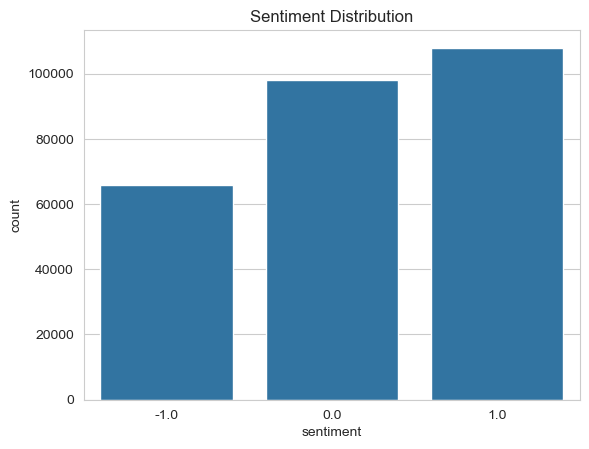

In [6]:
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

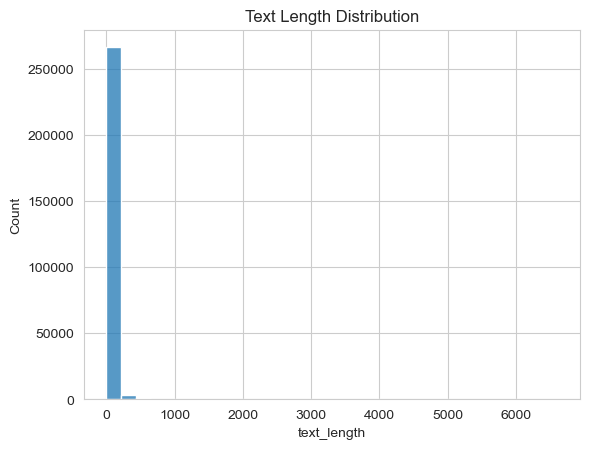

In [7]:
df["text_length"] = df["text"].apply(lambda x: len(x))

sns.histplot(df["text_length"], bins=30)
plt.title("Text Length Distribution")
plt.show()

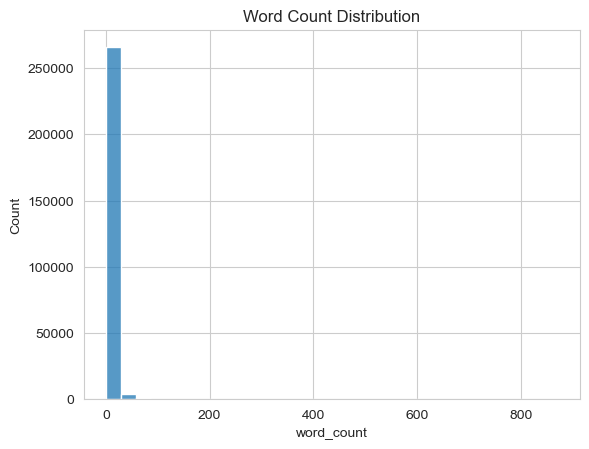

In [8]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

sns.histplot(df["word_count"], bins=30)
plt.title("Word Count Distribution")
plt.show()

In [9]:
df["sentiment"].value_counts(normalize=True)

sentiment
 1.0    0.397305
 0.0    0.360561
-1.0    0.242134
Name: proportion, dtype: float64

In [10]:
df.sample(10)

,text,sentiment,text_length,word_count
155281,would nearly impossible get point immobile bed...,-1.0,86,12
132514,rather upset scores us,0.0,22,4
163732,name hungry little bastard,-1.0,26,4
134874,feel like venting happy listen,1.0,30,5
66741,man making reconsider buying jersey,0.0,35,5
121983,spilled sperm allowances non returnable,0.0,39,5
20371,company present hold shares,0.0,27,4
82560,oh name awkward,-1.0,15,3
155741,happens every time playing sibling someone acc...,0.0,74,11
220049,name got lucky wasnt foul,1.0,25,5


In [11]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

sample = df["text"].iloc[0]

tokens = tokenizer.encode(sample)

print("Text:", sample)
print("Token Count:", len(tokens))
print("First 20 Tokens:", tokens[:20])

Text: spicejet issue crore warrants promoters
Token Count: 9
First 20 Tokens: [101, 17688, 15759, 3277, 21665, 10943, 2015, 26512, 102]


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (217334, 4)
Test: (54334, 4)


In [14]:
df.to_csv("data/cleaned_data.csv", index=False)

🔍 Key Observations:

- Dataset contains short financial news headlines
- Binary sentiment classification (0 = Negative, 1 = Positive)
- Missing text values required cleaning
- Text length is small → ideal for BERT
- Slight class imbalance present
- Financial domain vocabulary → benefits from fine-tuning

📈 Conclusion:
Transformer-based models (BERT/FinBERT) are highly suitable for this dataset.

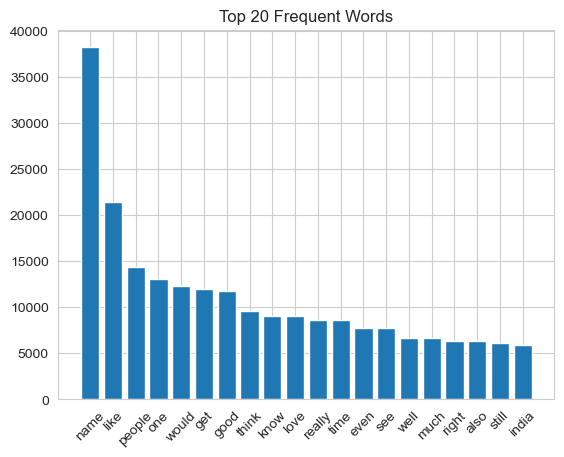

In [15]:
from collections import Counter

all_words = " ".join(df["text"]).split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.show()